In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

  # Use columns from your actual dataset
  X_raw = df["tenure"].values  # Independent variable (tenure)
  Y_raw = pd.to_numeric(
      df["TotalCharges"], errors="coerce"
  )  # Target variable (TotalCharges)

  # Clean out any missing/NaN values if they crop up
  valid_idx = ~np.isnan(Y_raw)
  X_raw = X_raw[valid_idx]
  Y_raw = Y_raw[valid_idx]

except FileNotFoundError:
  print(
      "CSV file not found! Generating dummy data for demonstration purposes."
  )
  np.random.seed(42)
  X_raw = np.linspace(500, 3500, 100)
  Y_raw = 50 * X_raw + 15000 + np.random.normal(0, 10000, 100)

# Normalize features to help gradient descent converge faster and more stably
X_mean = np.mean(X_raw)
X_std = np.std(X_raw)
X = (X_raw - X_mean) / X_std

Y = Y_raw

print("Data loaded and preprocessed successfully!")

Data loaded and preprocessed successfully!


Epoch 100/1000 | Cost: 1412515.8980
Epoch 200/1000 | Cost: 896496.2276
Epoch 300/1000 | Cost: 827360.0800
Epoch 400/1000 | Cost: 818097.2414
Epoch 500/1000 | Cost: 816856.2093
Epoch 600/1000 | Cost: 816689.9362
Epoch 700/1000 | Cost: 816667.6590
Epoch 800/1000 | Cost: 816664.6743
Epoch 900/1000 | Cost: 816664.2744
Epoch 1000/1000 | Cost: 816664.2208

--- Training Complete ---
Optimized Intercept (theta_0): 2283.2019
Optimized Slope (theta_1): 1871.8682


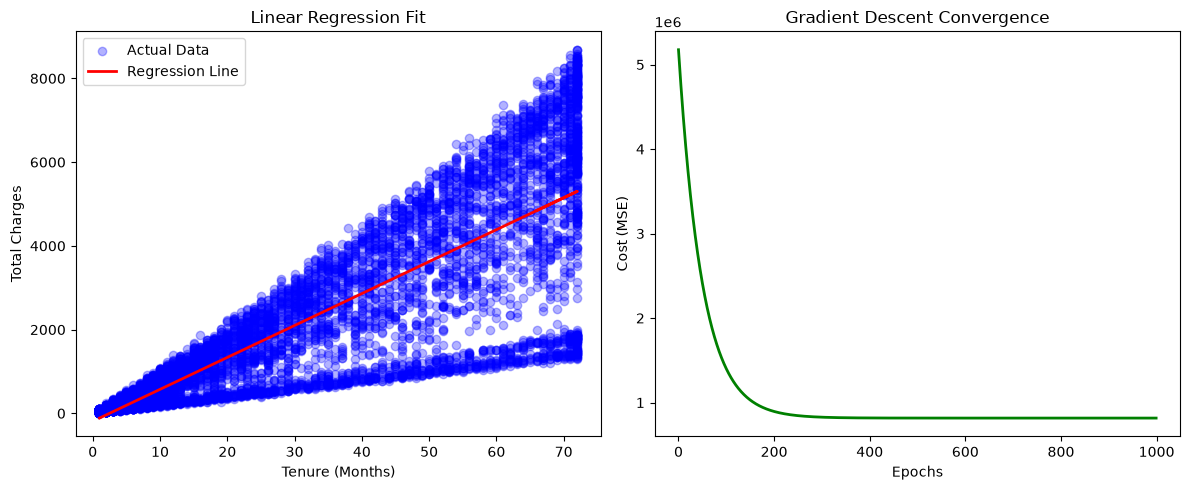

In [14]:
# 1. Initialize Parameters and Hyperparameters
m = len(X)  # Number of training examples
theta_0 = 0.0  # Intercept (bias)
theta_1 = 0.0  # Slope (weight)
learning_rate = 0.01
epochs = 1000

# 2. Gradient Descent Algorithm
cost_history = []

for epoch in range(epochs):
  # Predictions (Hypothesis function: h_theta(x) = theta_0 + theta_1 * x)
  Y_pred = theta_0 + theta_1 * X

  # Calculate Mean Squared Error (Cost function)
  cost = (1 / (2 * m)) * np.sum((Y_pred - Y) ** 2)
  cost_history.append(cost)

  # Calculate gradients (partial derivatives)
  d_theta_0 = (1 / m) * np.sum(Y_pred - Y)
  d_theta_1 = (1 / m) * np.sum((Y_pred - Y) * X)

  # Update parameters
  theta_0 -= learning_rate * d_theta_0
  theta_1 -= learning_rate * d_theta_1

  # Print progress every 100 epochs
  if (epoch + 1) % 100 == 0:
    print(f"Epoch {epoch+1}/{epochs} | Cost: {cost:.4f}")

print("\n--- Training Complete ---")
print(f"Optimized Intercept (theta_0): {theta_0:.4f}")
print(f"Optimized Slope (theta_1): {theta_1:.4f}")

# 3. Visualizing the Results
plt.figure(figsize=(12, 5))

# Plot 1: Data points and Regression Line
plt.subplot(1, 2, 1)
plt.scatter(X_raw, Y, color="blue", alpha=0.3, label="Actual Data")
Y_line_pred = theta_0 + theta_1 * X
plt.plot(
    X_raw, Y_line_pred, color="red", linewidth=2, label="Regression Line"
)
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")
plt.title("Linear Regression Fit")
plt.legend()

# Plot 2: Cost Function Reduction over Epochs
plt.subplot(1, 2, 2)
plt.plot(range(epochs), cost_history, color="green", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")

plt.tight_layout()
plt.show()